In [224]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [225]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.width', 500)

In [226]:
def load_dataset():
    df = pd.read_csv("data/wdbc_data.csv", index_col=0)
    return df

In [227]:
def check_df(dataframe):
    """
    Checks the overall structure and key metrics of a DataFrame.

    Args:
        dataframe (pd.DataFrame): DataFrame to inspect.

    Returns:
        None: Prints shape, data types, head, tail, missing values, and quantiles.
    """
    print("##################### Shape #####################")
    print(dataframe.shape)
    print("##################### Types #####################")
    print(dataframe.dtypes)
    print("##################### Head #####################")
    print(dataframe.head(5))
    print("##################### Tail #####################")
    print(dataframe.tail(5))
    print("##################### NA #####################")
    print(dataframe.isnull().sum())
    print('##################### Unique Values #####################')
    print(dataframe.nunique())
    print("##################### Duplicates #####################")
    print(dataframe.duplicated().sum())
    print("##################### Quantiles #####################")
    # Uncomment below to include quantile information
    #print(dataframe[[col for col in dataframe.columns if dataframe[col].dtypes != "O"]].quantile([0, 0.05, 0.50, 0.75, 0.95, 0.99, 1]).T)
    print(dataframe.describe().T)

In [228]:
df = load_dataset()

In [229]:
check_df(df)

##################### Shape #####################
(569, 32)
##################### Types #####################
ID                      int64
Diagnosis               int64
radius1               float64
texture1              float64
perimeter1            float64
area1                 float64
smoothness1           float64
compactness1          float64
concavity1            float64
concave_points1       float64
symmetry1             float64
fractal_dimension1    float64
radius2               float64
texture2              float64
perimeter2            float64
area2                 float64
smoothness2           float64
compactness2          float64
concavity2            float64
concave_points2       float64
symmetry2             float64
fractal_dimension2    float64
radius3               float64
texture3              float64
perimeter3            float64
area3                 float64
smoothness3           float64
compactness3          float64
concavity3            float64
concave_points3     

**BAYESIAN NETWORK**

In [230]:
import bnlearn as bn
from pgmpy.models.LinearGaussianBayesianNetwork import LinearGaussianBayesianNetwork

In [231]:
dependencies_structure = bn.structure_learning.fit(df=df, methodtype='hc', scoretype='bic')

[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).


In [232]:
bn.plot(dependencies_structure)

[bnlearn]> Nothing to plot because no edges are present between nodes. 


In [233]:
def correlation_matrix(df, cols):
    """
    Visualizes the correlation matrix for specified columns.

    Args:
        df (pd.DataFrame): DataFrame to analyze.
        cols (list): List of columns to include in the correlation matrix.

    Returns:
        None: Displays a heatmap.
    """
    fig = plt.gcf()
    fig.set_size_inches(20, 16)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    fig = sns.heatmap(df[cols].corr(), annot=True, linewidths=0.5,
                      annot_kws={'size': 8}, linecolor='w', cmap='vlag')
    plt.show(block=True)

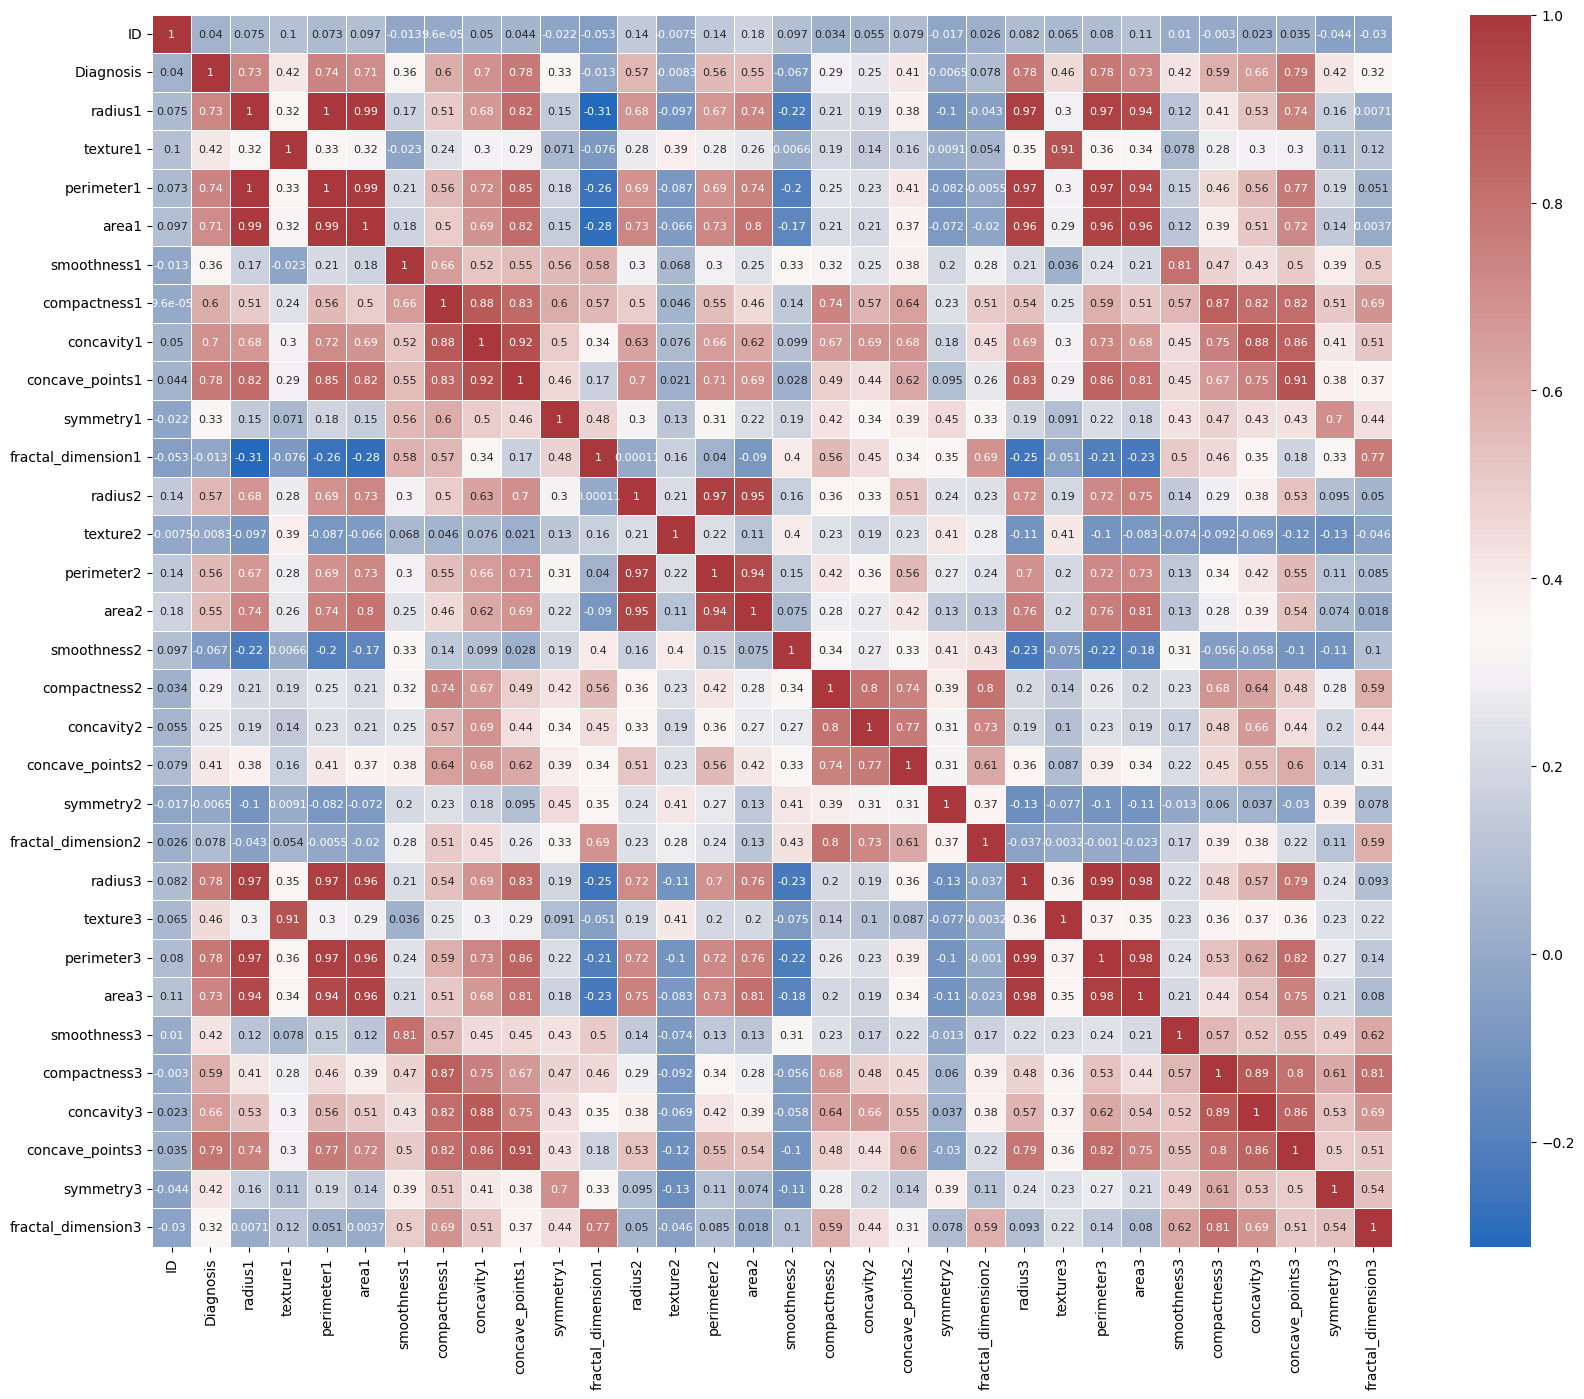

In [234]:
correlation_matrix(df=df, cols=df.columns)

**OBSERVATIONS**
- No dependencies were found but correlation matrix shows a contrast result.
- Probably, function parameters or scoring tecnique did not suit well for our continious features and small dataset

In [235]:
dependencies_structure = bn.structure_learning.fit(df=df, methodtype='hc', scoretype='aic') #trying another scoring technique

[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [aic]
[bnlearn] >Compute structure scores for model comparison (higher is better).


In [236]:
bn.plot(dependencies_structure)

[bnlearn]> Nothing to plot because no edges are present between nodes. 


Scoring based methods cant find a dependency so we switch to statistical tests based methods

In [237]:
dependencies_structure = bn.structure_learning.fit(df=df, methodtype='cs')

[bnlearn] >Computing best DAG using [cs]
[bnlearn] >Build skeleton with [chi_square] and alpha=0.05


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Warning: Structure scoring could not be computed. Method [cs] not supported.


**Strategy: Discretization**

In [238]:
#df.drop(columns=['ID'], axis=1, inplace=True)

In [239]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size=0.20, random_state=26)

In [240]:
check_df(df_train)

##################### Shape #####################
(455, 32)
##################### Types #####################
ID                      int64
Diagnosis               int64
radius1               float64
texture1              float64
perimeter1            float64
area1                 float64
smoothness1           float64
compactness1          float64
concavity1            float64
concave_points1       float64
symmetry1             float64
fractal_dimension1    float64
radius2               float64
texture2              float64
perimeter2            float64
area2                 float64
smoothness2           float64
compactness2          float64
concavity2            float64
concave_points2       float64
symmetry2             float64
fractal_dimension2    float64
radius3               float64
texture3              float64
perimeter3            float64
area3                 float64
smoothness3           float64
compactness3          float64
concavity3            float64
concave_points3     

In [241]:
from sklearn.preprocessing import KBinsDiscretizer
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')

**Quantile based discretization is applied to combat outlier and noise affect on data.**

In [242]:
cols_without_target_and_id = [col for col in df.columns if col not in ['ID', 'Diagnosis']]

In [243]:
df_train_discrete = pd.DataFrame(discretizer.fit_transform(df_train[cols_without_target_and_id]), 
                                 columns=cols_without_target_and_id)

df_train_discrete['Diagnosis'] = df_train['Diagnosis'].values

df_test_discrete = pd.DataFrame(discretizer.transform(df_test[cols_without_target_and_id]), 
                                columns=cols_without_target_and_id)

df_test_discrete['Diagnosis'] = df_test['Diagnosis'].values

In [244]:
check_df(df_train_discrete)

##################### Shape #####################
(455, 31)
##################### Types #####################
radius1               float64
texture1              float64
perimeter1            float64
area1                 float64
smoothness1           float64
compactness1          float64
concavity1            float64
concave_points1       float64
symmetry1             float64
fractal_dimension1    float64
radius2               float64
texture2              float64
perimeter2            float64
area2                 float64
smoothness2           float64
compactness2          float64
concavity2            float64
concave_points2       float64
symmetry2             float64
fractal_dimension2    float64
radius3               float64
texture3              float64
perimeter3            float64
area3                 float64
smoothness3           float64
compactness3          float64
concavity3            float64
concave_points3       float64
symmetry3             float64
fractal_dimension3  

**SCALING**

In [245]:
from sklearn.preprocessing import MinMaxScaler

In [246]:
scaler = MinMaxScaler()

In [247]:
df_train_discrete = pd.DataFrame(scaler.fit_transform(df_train_discrete[cols_without_target_and_id]), columns=cols_without_target_and_id)
df_train_discrete['Diagnosis'] = df_train['Diagnosis'].values

df_test_discrete = pd.DataFrame(scaler.transform(df_test_discrete[cols_without_target_and_id]), columns=cols_without_target_and_id)
df_test_discrete['Diagnosis'] = df_test['Diagnosis'].values

[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


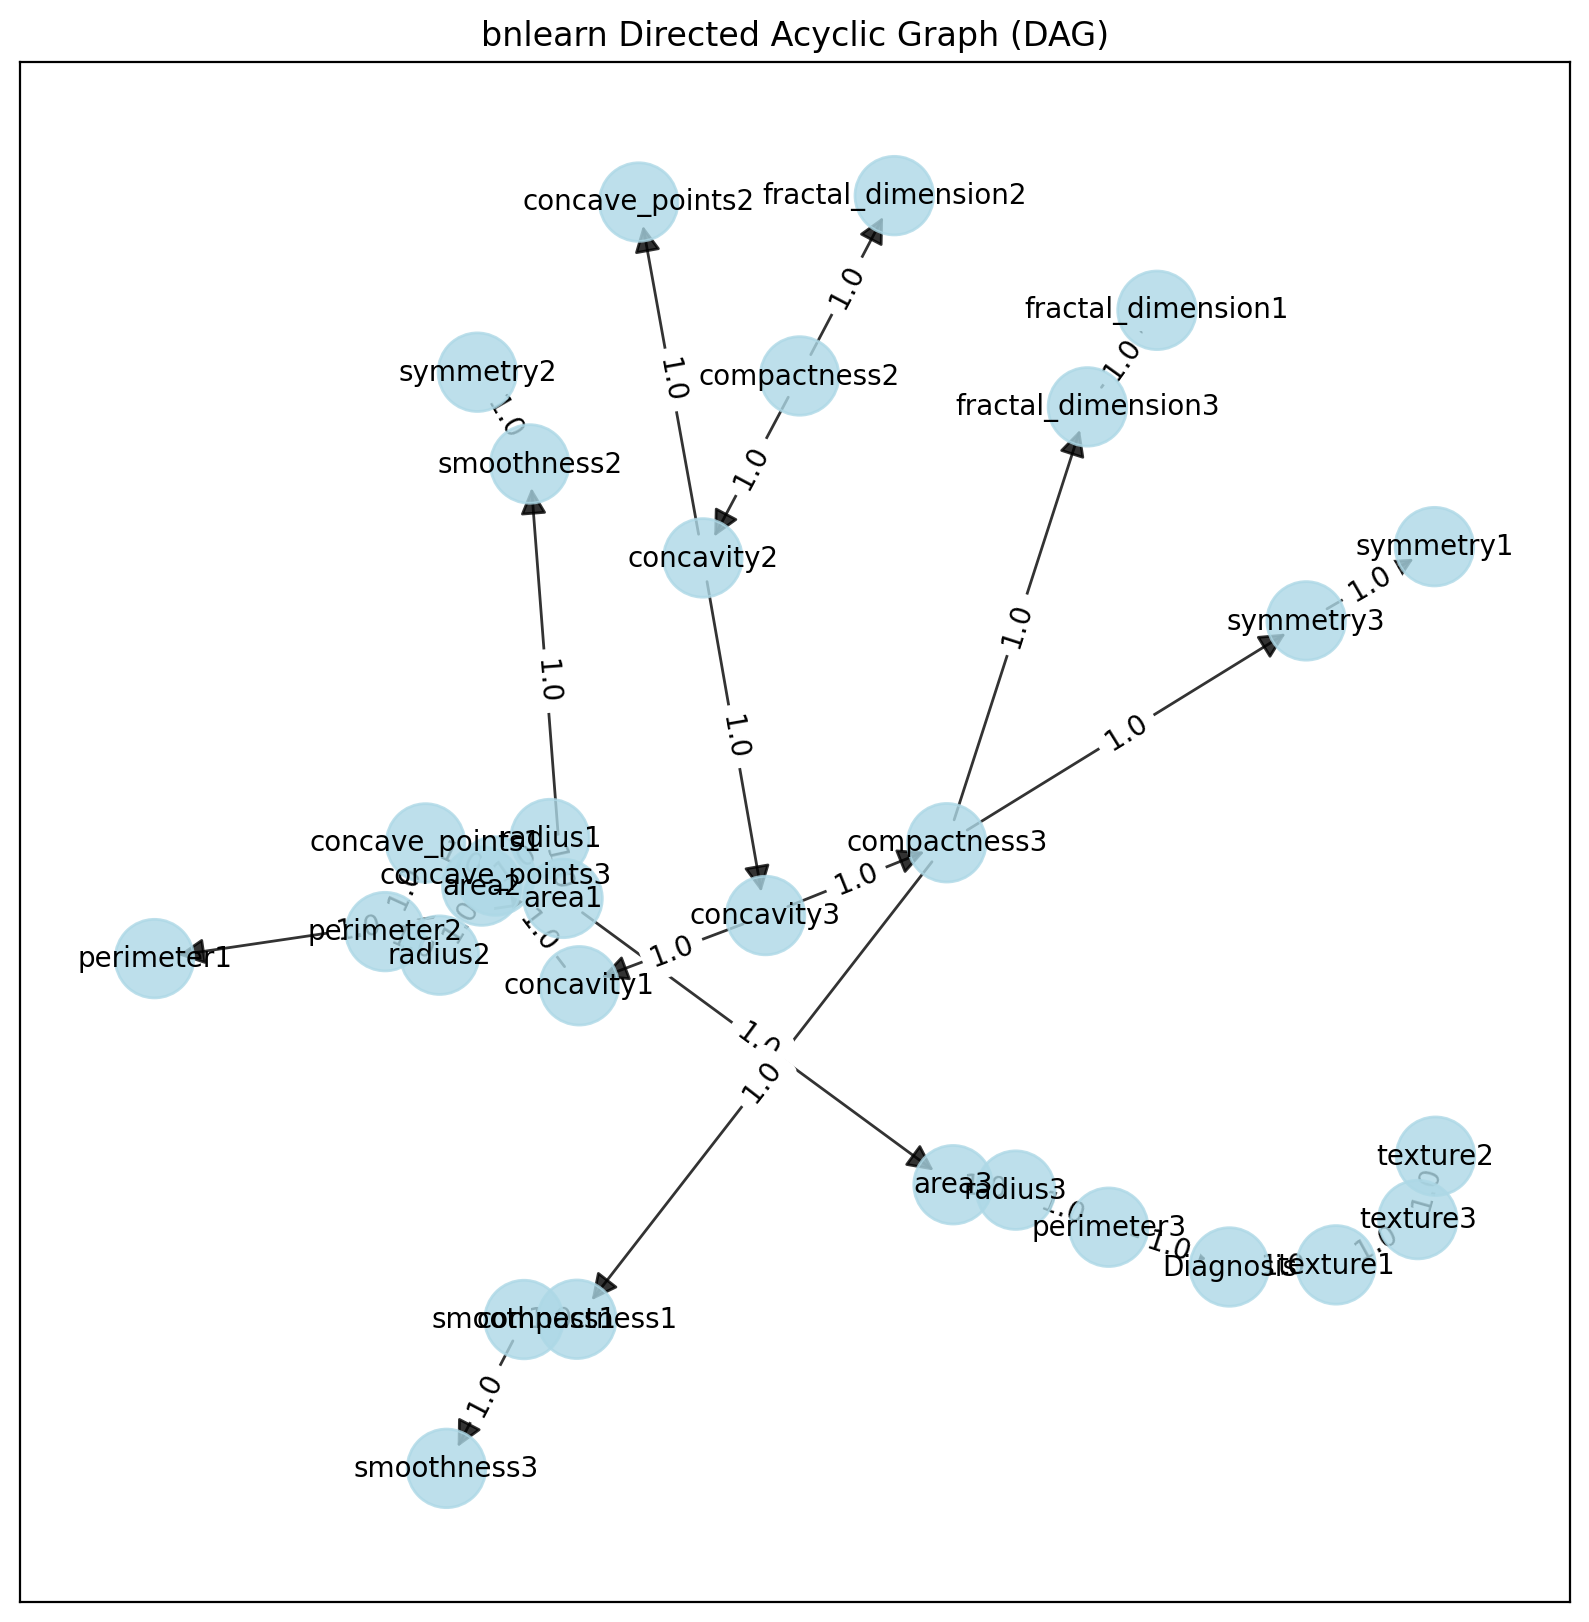

{'fig': <Figure size 2000x2000 with 1 Axes>,
 'ax': <Figure size 2000x2000 with 1 Axes>,
 'pos': {'radius1': array([-0.38901473,  0.02495405]),
  'area1': array([-0.36889298, -0.05147636]),
  'texture1': array([ 0.82516142, -0.51953346]),
  'texture3': array([ 0.95147749, -0.46169124]),
  'perimeter1': array([-1.        , -0.12838919]),
  'smoothness2': array([-0.42039259,  0.50338012]),
  'area3': array([ 0.23363306, -0.41718122]),
  'smoothness1': array([-0.42917456, -0.58934962]),
  'smoothness3': array([-0.54897186, -0.77942441]),
  'compactness1': array([-0.34755967, -0.58899197]),
  'concavity1': array([-0.34393923, -0.16306527]),
  'concave_points3': array([-0.47342014, -0.02292138]),
  'concave_points1': array([-0.58125687,  0.01933242]),
  'perimeter2': array([-0.64383184, -0.09389257]),
  'radius2': array([-0.55962681, -0.12398706]),
  'area2': array([-0.49452614, -0.03573713]),
  'symmetry2': array([-0.50123437,  0.62058691]),
  'compactness2': array([-0.00352471,  0.6157856

In [248]:
dependencies_structure = bn.structure_learning.fit(df_train_discrete, methodtype='hc', scoretype='bic')


bn.plot(dependencies_structure)

In [249]:
bayesian_network_model = bn.parameter_learning.fit(dependencies_structure, df_train_discrete)

[bnlearn] >Parameter learning> Computing parameters using [bayes]
[bnlearn] >Converting [<class 'pgmpy.base.DAG.DAG'>] to BayesianNetwork model.
[bnlearn] >Converting adjmat to BayesianNetwork.
[bnlearn] >CPD of radius1:
+---------------+-----+---------------------+
| area2         | ... | area2(1.0)          |
+---------------+-----+---------------------+
| radius1(0.0)  | ... | 0.13745704467353953 |
+---------------+-----+---------------------+
| radius1(0.25) | ... | 0.13745704467353953 |
+---------------+-----+---------------------+
| radius1(0.5)  | ... | 0.13745704467353953 |
+---------------+-----+---------------------+
| radius1(0.75) | ... | 0.19243986254295534 |
+---------------+-----+---------------------+
| radius1(1.0)  | ... | 0.3951890034364261  |
+---------------+-----+---------------------+
[bnlearn] >CPD of area1:
+-------------+---------------------+-----+---------------------+
| radius1     | radius1(0.0)        | ... | radius1(1.0)        |
+-------------+---------

In [250]:
X_train = df_train_discrete[cols_without_target_and_id]
y_train = df_train_discrete['Diagnosis']

X_test = df_test_discrete[cols_without_target_and_id]
y_test = df_test_discrete['Diagnosis']

In [251]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, 
                             roc_auc_score, roc_curve, precision_recall_curve, auc,
                             classification_report, accuracy_score)
from sklearn.calibration import calibration_curve

In [252]:
y_pred = bn.predict(bayesian_network_model, X_test, variables=['Diagnosis'])

[bnlearn]> Remaining columns for inference: 30


100%|██████████| 114/114 [00:00<00:00, 352.35it/s]


In [253]:
y_pred = y_pred['Diagnosis'].values

In [254]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.9649122807017544

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        74
           1       0.95      0.95      0.95        40

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



In [255]:
y_prob = []
for i in range(len(X_test)):

    query = bn.inference.fit(bayesian_network_model, variables=['Diagnosis'], 
                             evidence=X_test.iloc[i].to_dict(), 
                             verbose=0)

    prob_val = query.values[1] 
    y_prob.append(prob_val)

y_prob = np.array(y_prob)

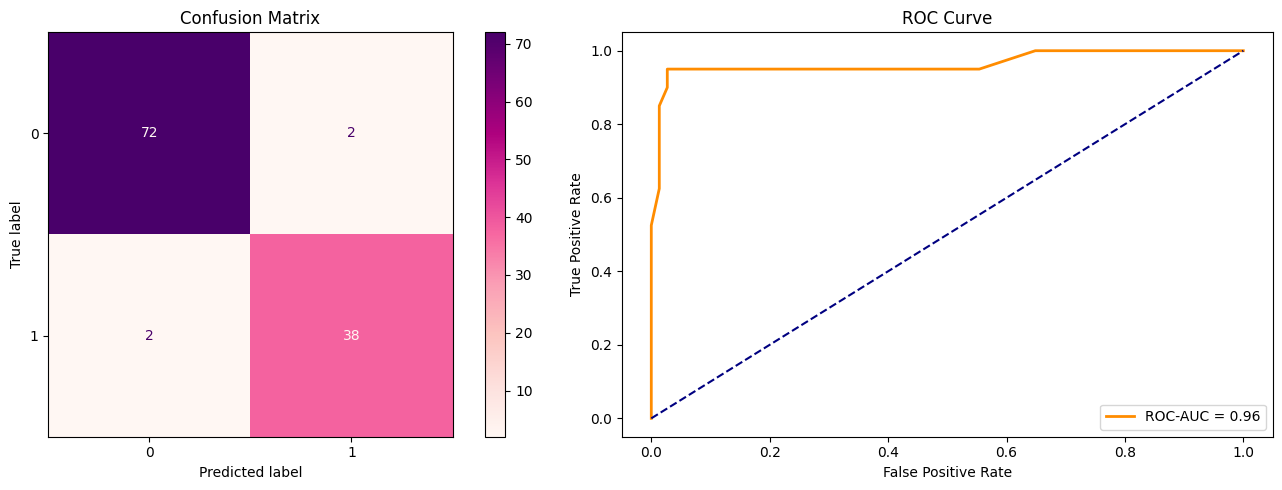

PR-AUC (Precision-Recall AUC): 0.9594


In [256]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], cmap='RdPu')
ax[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.2f}', color='darkorange', lw=2)
ax[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Curve')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
print(f"PR-AUC (Precision-Recall AUC): {pr_auc:.4f}")

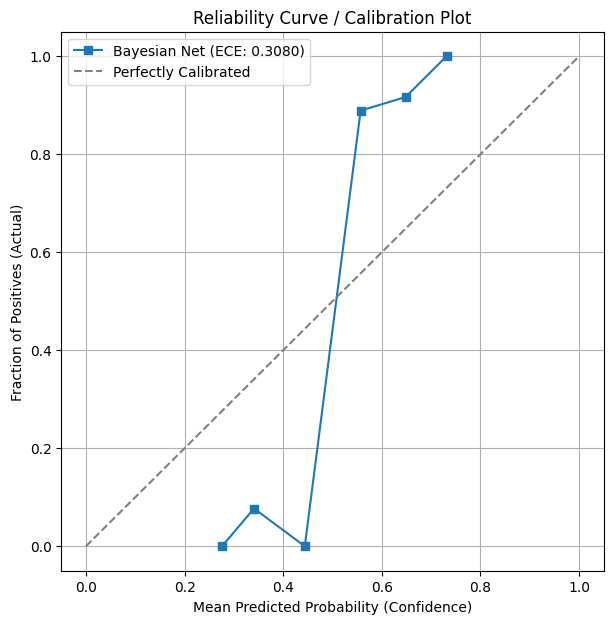

In [257]:
def calculate_ece(y_true, y_prob, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    ece = 0
    for j in range(n_bins):
        mask = binids == j
        if np.any(mask):
            weight = np.mean(mask)
            diff = np.abs(np.mean(y_true[mask]) - np.mean(y_prob[mask]))
            ece += weight * diff
    return ece

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
ece_val = calculate_ece(y_test, y_prob)

plt.figure(figsize=(7, 7))
plt.plot(prob_pred, prob_true, marker='s', ls='-', label=f'Bayesian Net (ECE: {ece_val:.4f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability (Confidence)')
plt.ylabel('Fraction of Positives (Actual)')
plt.title('Reliability Curve / Calibration Plot')
plt.legend()
plt.grid(True)
plt.show()

**CART MODELING**

In [258]:
from sklearn.tree import DecisionTreeClassifier

In [259]:
cart_model = DecisionTreeClassifier(criterion='gini')

In [260]:
cart_model = cart_model.fit(X=X_train, y=y_train)

In [261]:
y_pred_cart = cart_model.predict(X_test)

y_prob_cart = cart_model.predict_proba(X_test)[:, 1]

CART Model Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95        74
           1       0.90      0.93      0.91        40

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



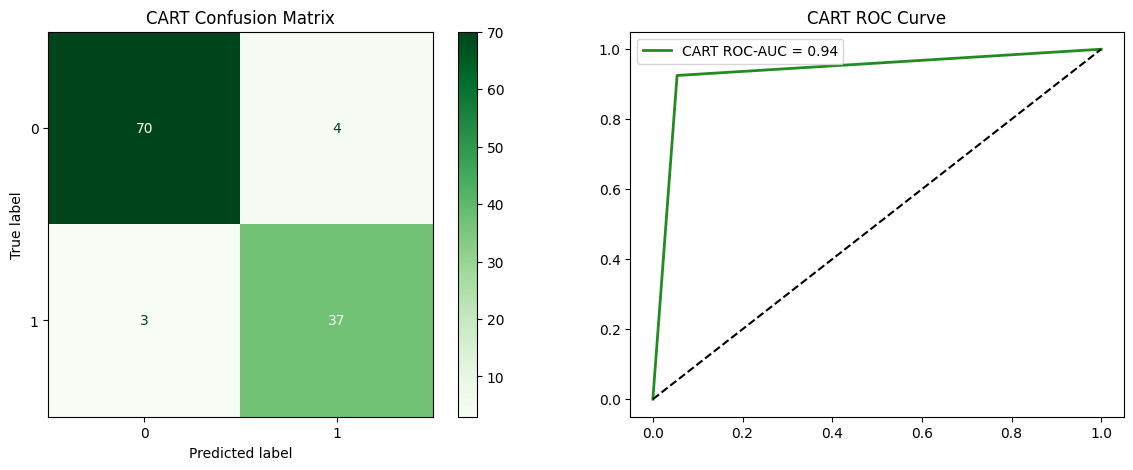

CART PR-AUC: 0.9269


In [262]:
# Classification Report 
print("CART Model Classification Report:")
print(classification_report(y_test, y_pred_cart))

# Confusion Matrix and ROC Curve
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_cart, ax=ax[0], cmap='Greens')
ax[0].set_title("CART Confusion Matrix")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_cart)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, label=f'CART ROC-AUC = {roc_auc:.2f}', color='forestgreen', lw=2)
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title("CART ROC Curve")
ax[1].legend()

plt.show()

# PR-AUC
precision, recall, _ = precision_recall_curve(y_test, y_prob_cart)
print(f"CART PR-AUC: {auc(recall, precision):.4f}")

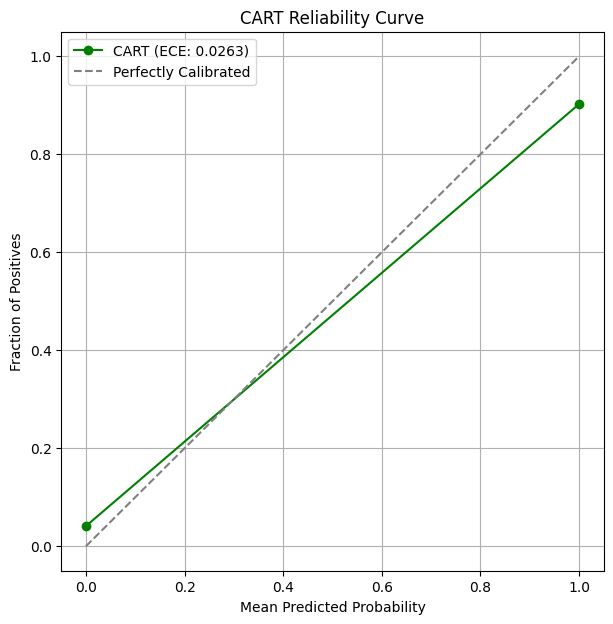

In [263]:
# Reliability Curve
prob_true, prob_pred = calibration_curve(y_test, y_prob_cart, n_bins=10)
ece_cart = calculate_ece(y_test, y_prob_cart) 

plt.figure(figsize=(7, 7))
plt.plot(prob_pred, prob_true, marker='o', ls='-', label=f'CART (ECE: {ece_cart:.4f})', color='green')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('CART Reliability Curve')
plt.legend()
plt.grid(True)
plt.show()

**CATEGORICAL-NB MODELING**

In [264]:
from sklearn.naive_bayes import CategoricalNB

In [265]:
categorical_nb_model = CategoricalNB(alpha=1)

In [266]:
categorical_nb_model = categorical_nb_model.fit(X=X_train, y=y_train)

In [267]:
y_pred_nb = categorical_nb_model.predict(X_test)

y_prob_nb = categorical_nb_model.predict_proba(X_test)[:, 1]

In [268]:
print("Categorical Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))

Categorical Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95        74
           1       0.92      0.90      0.91        40

    accuracy                           0.94       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



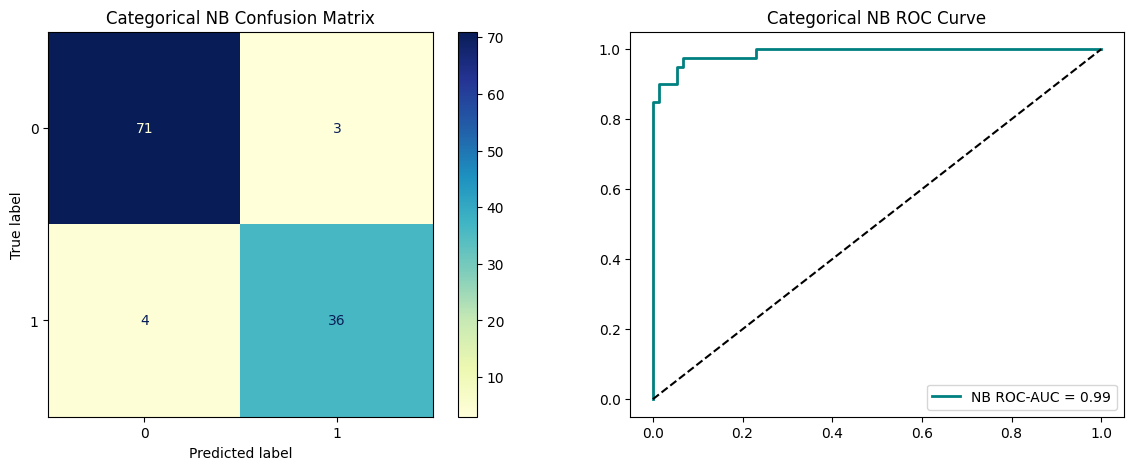

In [269]:
# Visualization: Confusion Matrix and ROC Curve
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb, ax=ax[0], cmap='YlGnBu')
ax[0].set_title("Categorical NB Confusion Matrix")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_nb)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, label=f'NB ROC-AUC = {roc_auc:.2f}', color='teal', lw=2)
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title("Categorical NB ROC Curve")
ax[1].legend()
plt.show()

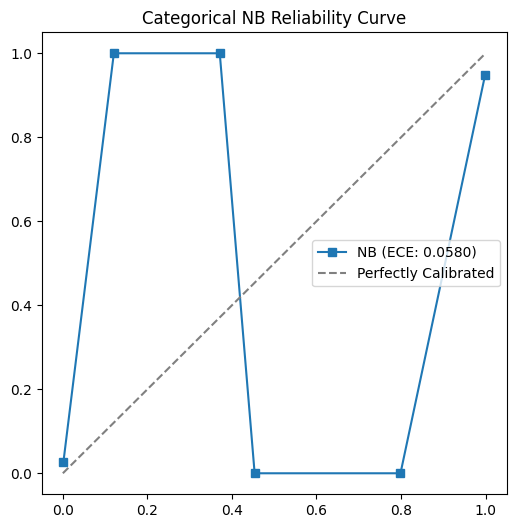

In [270]:
# Reliability Curve and ECE
prob_true_nb, prob_pred_nb = calibration_curve(y_test, y_prob_nb, n_bins=10)
ece_nb = calculate_ece(y_test, y_prob_nb) # Using the function defined previously

plt.figure(figsize=(6, 6))
plt.plot(prob_pred_nb, prob_true_nb, marker='s', label=f'NB (ECE: {ece_nb:.4f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfectly Calibrated')
plt.title('Categorical NB Reliability Curve')
plt.legend()
plt.show()

**SVM MODELING**

In [271]:
from sklearn.svm import SVC

In [272]:
svm_linear_model = SVC(kernel='linear', probability=True, random_state=42)
svm_rbf_model = SVC(kernel='rbf', probability=True, random_state=42)

In [273]:
svm_linear_model = svm_linear_model.fit(X=X_train, y=y_train)
svm_rbf_model = svm_rbf_model.fit(X=X_train, y=y_train)


Evaluating SVM Linear...
SVM Linear Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        74
           1       0.93      0.97      0.95        40

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



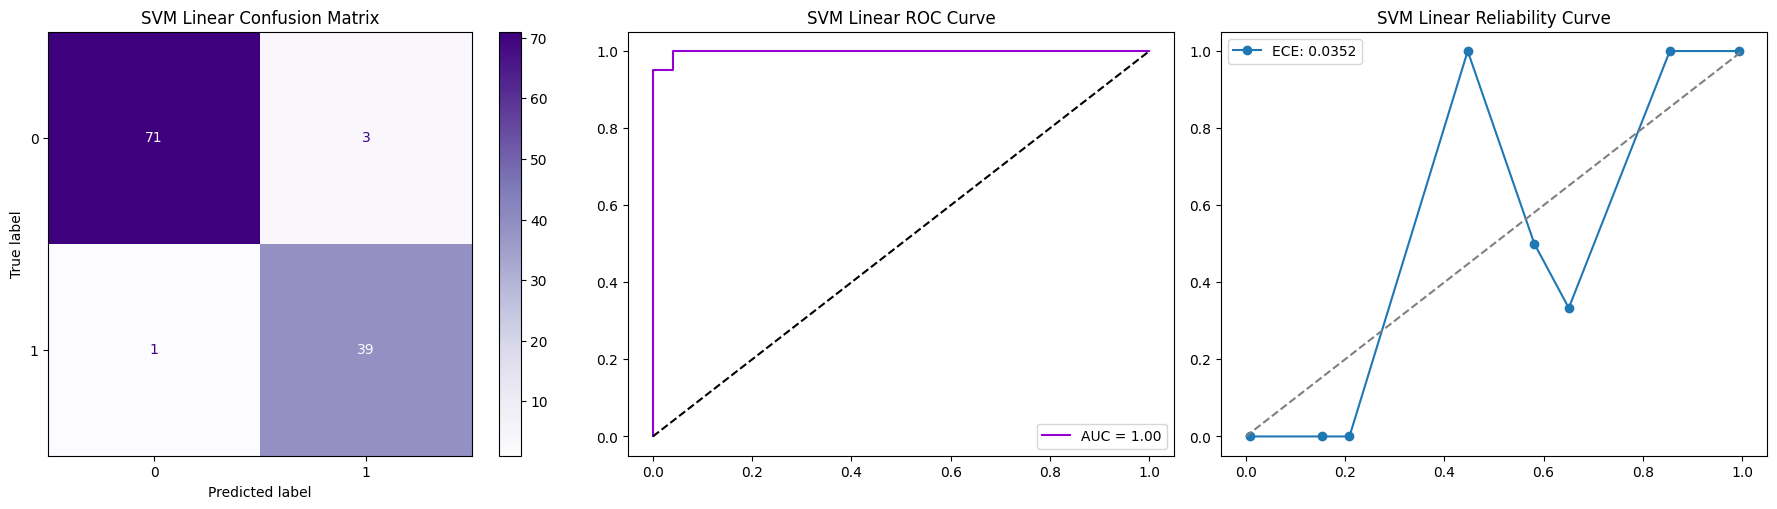


Evaluating SVM RBF...
SVM RBF Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        74
           1       0.98      1.00      0.99        40

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



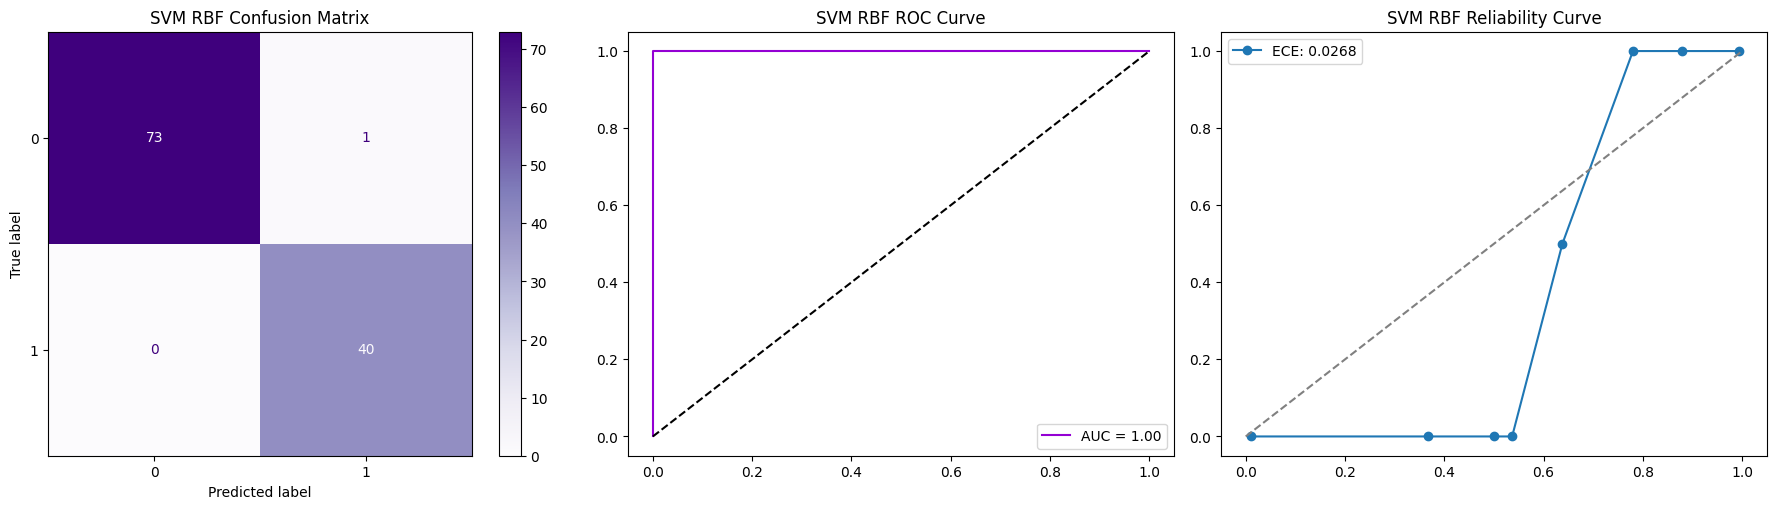

In [274]:
# Store in a list for iteration
svm_list = [
    ("SVM Linear", svm_linear_model),
    ("SVM RBF", svm_rbf_model)
]

# Evaluation Loop 
X_test_svm = df_test_discrete[cols_without_target_and_id]

for name, model in svm_list:
    print(f"\nEvaluating {name}...")
    
    # Generate predictions
    y_pred = model.predict(X_test_svm)
    y_prob = model.predict_proba(X_test_svm)[:, 1]
    
    # Classification Report
    print(f"{name} Report:")
    print(classification_report(y_test, y_pred))
    
    # Visualization
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    
    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], cmap='Purples')
    ax[0].set_title(f"{name} Confusion Matrix")
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax[1].plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}', color='darkviolet')
    ax[1].plot([0, 1], [0, 1], 'k--')
    ax[1].set_title(f"{name} ROC Curve")
    ax[1].legend()
    
    # Reliability Curve (using the calculate_ece function from before)
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
    ece_val = calculate_ece(y_test, y_prob)
    ax[2].plot(prob_pred, prob_true, marker='o', label=f'ECE: {ece_val:.4f}')
    ax[2].plot([0, 1], [0, 1], '--', color='gray')
    ax[2].set_title(f"{name} Reliability Curve")
    ax[2].legend()
    
    plt.tight_layout()
    plt.show()

## Clustering Implementations

In [275]:
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

In [276]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test)

In [ ]:
def evaluate_clustering(models, X, y_true, X_pca):
    results = []
    
    fig, axes = plt.subplots(1, len(models), figsize=(20, 5))
    
    for idx, (name, model) in enumerate(models):
        # Tahminleme
        if name == "GMM":
            y_cluster = model.fit_predict(X)
        else:
            y_cluster = model.fit_predict(X)
            
        # Metrikler
        sil_score = silhouette_score(X, y_cluster)
        ari_score = adjusted_rand_score(y_true, y_cluster)
        
        results.append({
            "Model": name,
            "Silhouette": sil_score,
            "ARI (Ground Truth Match)": ari_score
        })
        
        # Görselleştirme
        sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_cluster, palette='viridis', ax=axes[idx], s=50)
        axes[idx].set_title(f"{name}\nSil: {sil_score:.2f} | ARI: {ari_score:.2f}")
        axes[idx].legend([],[], frameon=False)

    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame(results)

In [278]:
clustering_models = [
    ("K-Means", KMeans(n_clusters=2, random_state=42, n_init=10)),
    ("GMM", GaussianMixture(n_components=2, random_state=42)),
    ("Spectral", SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=42)),
    ("Agglomerative", AgglomerativeClustering(n_clusters=2))
]

##################### CLUSTERING ANALYSIS (TABULAR) #####################


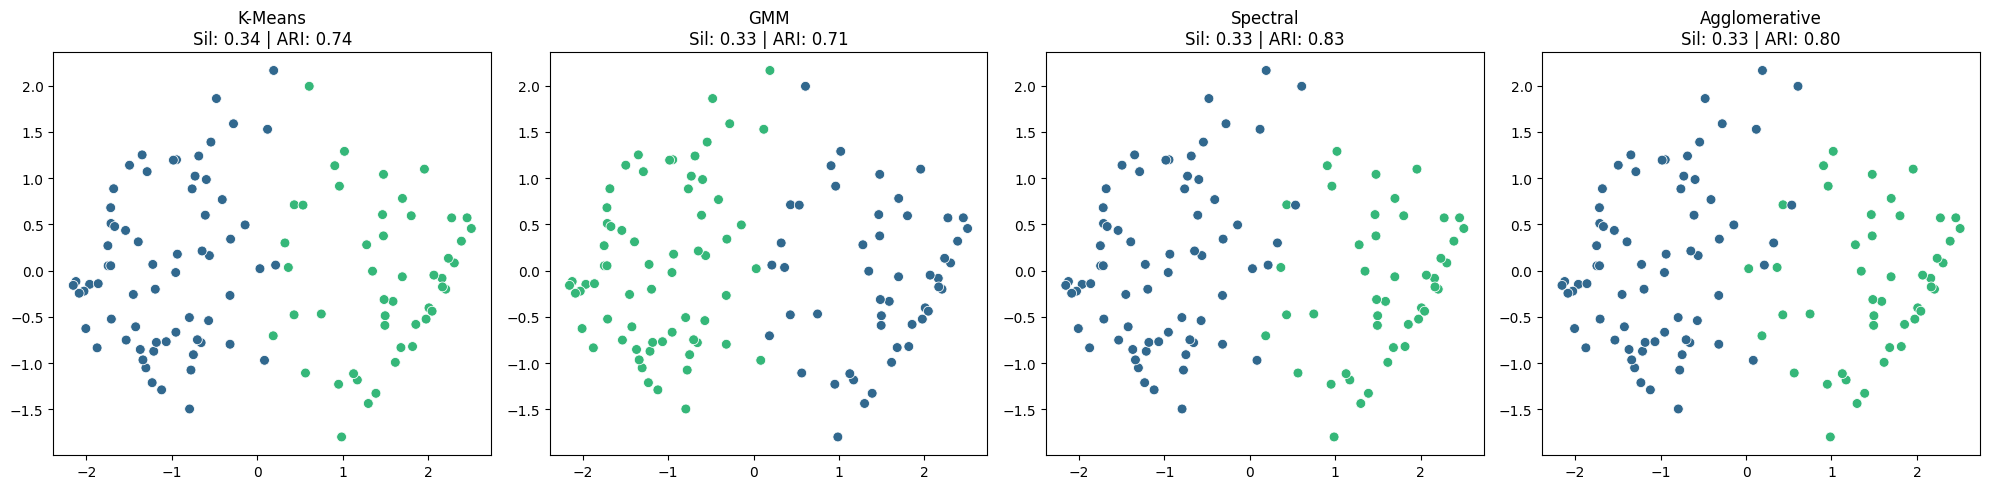


Clustering Performance Metrics:
           Model  Silhouette  ARI (Ground Truth Match)
0        K-Means       0.336                     0.736
1            GMM       0.335                     0.706
2       Spectral       0.334                     0.830
3  Agglomerative       0.331                     0.798


In [279]:
print("##################### CLUSTERING ANALYSIS (TABULAR) #####################")

cluster_results = evaluate_clustering(clustering_models, X_test, y_test, X_pca)

print("\nClustering Performance Metrics:")
print(cluster_results)

## Classification & Clustering on Untabular Data: TEXT

In [291]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import accuracy_score, silhouette_score, adjusted_rand_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [297]:
def load_news_train():
    df = pd.read_csv("data/train.csv")
    return df

def load_news_test():
    df = pd.read_csv("data/test.csv")
    return df

In [298]:
df_text_train = load_news_train()
df_text_test = load_news_test()

In [299]:
df_text_train = df_text_train.groupby('Class Index').head(1000).reset_index(drop=True)
df_text_test = df_text_test.groupby('Class Index').head(200).reset_index(drop=True)

In [300]:
check_df(df_text_train)

##################### Shape #####################
(4000, 3)
##################### Types #####################
Class Index     int64
Title          object
Description    object
dtype: object
##################### Head #####################
   Class Index                                              Title                                        Description
0            3  Wall St. Bears Claw Back Into the Black (Reuters)  Reuters - Short-sellers, Wall Street's dwindli...
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...  Reuters - Private investment firm Carlyle Grou...
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)  Reuters - Soaring crude prices plus worries\ab...
3            3  Iraq Halts Oil Exports from Main Southern Pipe...  Reuters - Authorities have halted oil export\f...
4            3  Oil prices soar to all-time record, posing new...  AFP - Tearaway world oil prices, toppling reco...
##################### Tail #####################
      Clas

In [301]:
check_df(df_text_test)

##################### Shape #####################
(800, 3)
##################### Types #####################
Class Index     int64
Title          object
Description    object
dtype: object
##################### Head #####################
   Class Index                                              Title                                        Description
0            3                  Fears for T N pension after talks  Unions representing workers at Turner   Newall...
1            4  The Race is On: Second Private Team Sets Launc...  SPACE.com - TORONTO, Canada -- A second\team o...
2            4      Ky. Company Wins Grant to Study Peptides (AP)  AP - A company founded by a chemistry research...
3            4      Prediction Unit Helps Forecast Wildfires (AP)  AP - It's barely dawn when Mike Fitzpatrick st...
4            4        Calif. Aims to Limit Farm-Related Smog (AP)  AP - Southern California's smog-fighting agenc...
##################### Tail #####################
     Class 

**PREPROCESSING**

In [302]:
df_text_train['Text'] = df_text_train['Title'] + " " + df_text_train['Description']
df_text_test['Text'] = df_text_test['Title'] + " " + df_text_test['Description']

In [303]:
y_text_train = df_text_train['Class Index'].values
y_text_test = df_text_test['Class Index'].values

**VECTORIZATION**

In [304]:
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X_text_train = vectorizer.fit_transform(df_text_train['Text']).toarray()
X_text_test = vectorizer.transform(df_text_test['Text']).toarray()

**DEFINING CLASSIFIERS**

In [305]:
text_classifiers = [
        ("Decision Tree", DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=42)),
        ("Multinomial NB", MultinomialNB()),
        ("SVM (Linear)", LinearSVC(dual=False, random_state=42))
    ]


Training Decision Tree on Text Data...
Decision Tree Accuracy: 0.4725

Training Multinomial NB on Text Data...
Multinomial NB Accuracy: 0.8113

Training SVM (Linear) on Text Data...
SVM (Linear) Accuracy: 0.7688


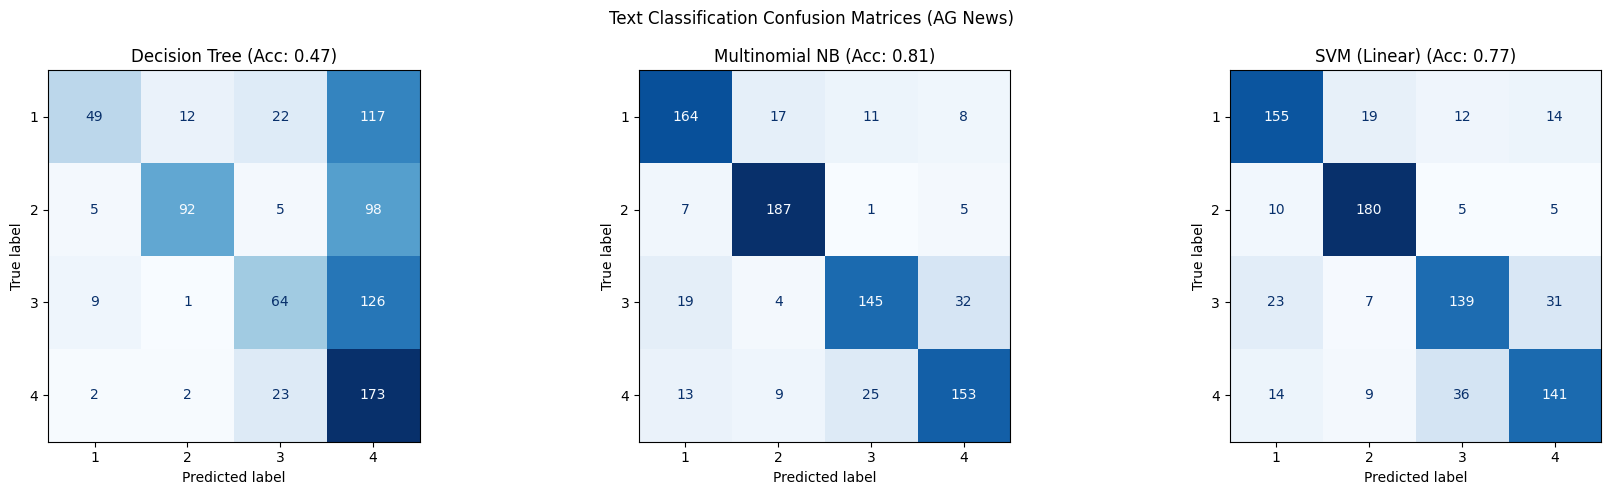

In [306]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(text_classifiers):
    print(f"\nTraining {name} on Text Data...")
    model.fit(X_text_train, y_text_train)
    y_pred_text = model.predict(X_text_test)
        
    # Accuracy
    acc = accuracy_score(y_text_test, y_pred_text)
    print(f"{name} Accuracy: {acc:.4f}")
        
    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_text_test, y_pred_text, ax=ax[i], cmap='Blues', colorbar=False)
    ax[i].set_title(f"{name} (Acc: {acc:.2f})")

plt.suptitle("Text Classification Confusion Matrices (AG News)")
plt.tight_layout()
plt.show()

**CLUSTERING ON TEXT DATA**

In [307]:
pca_text = PCA(n_components=2)
X_text_pca = pca_text.fit_transform(X_text_test)

In [308]:
n_clusters = 4 

text_clustering_models = [
    ("K-Means", KMeans(n_clusters=n_clusters, random_state=42, n_init=10)),
    ("Agglomerative", AgglomerativeClustering(n_clusters=n_clusters, linkage='ward'))
]

K-Means -> Silhouette Score: 0.013, ARI Score: 0.039
Agglomerative -> Silhouette Score: 0.011, ARI Score: 0.063


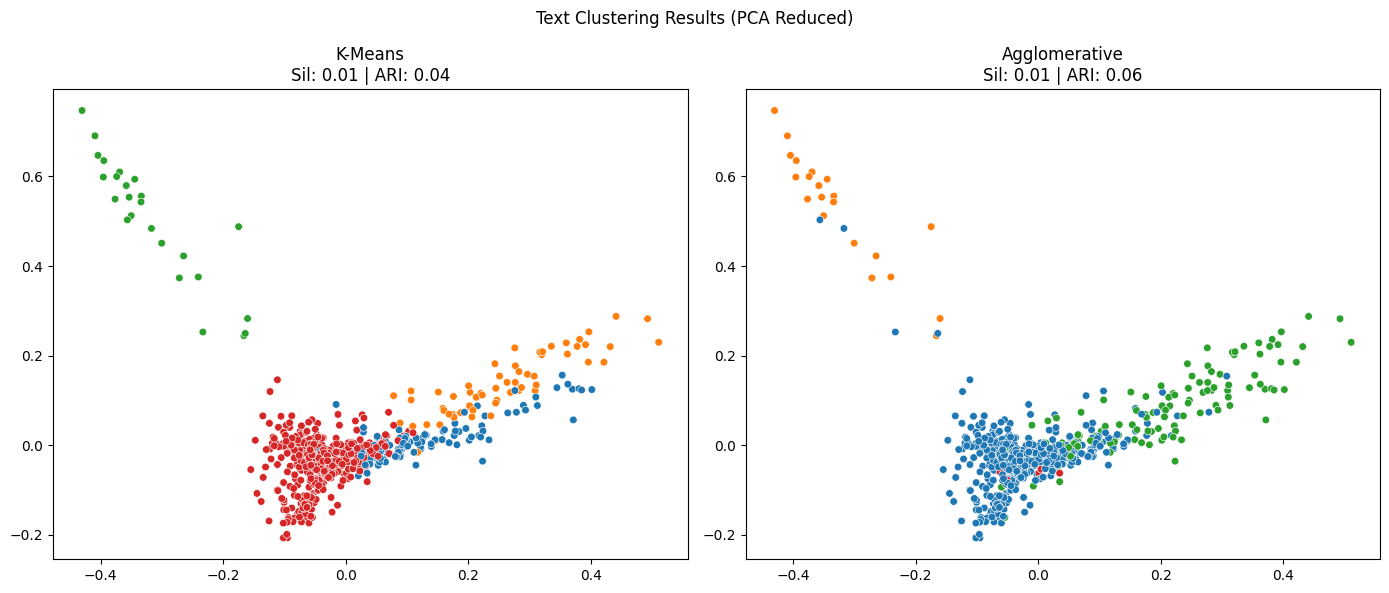

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (name, model) in enumerate(text_clustering_models):

    y_cluster_text = model.fit_predict(X_text_test)
    

    sil_text = silhouette_score(X_text_test, y_cluster_text)

    ari_text = adjusted_rand_score(y_text_test, y_cluster_text)
    
    print(f"{name} -> Silhouette Score: {sil_text:.3f}, ARI Score: {ari_text:.3f}")
    

    sns.scatterplot(x=X_text_pca[:, 0], y=X_text_pca[:, 1], hue=y_cluster_text, palette='tab10', ax=axes[idx], s=30)
    axes[idx].set_title(f"{name}\nSil: {sil_text:.2f} | ARI: {ari_text:.2f}")
    axes[idx].legend([],[], frameon=False)

plt.suptitle("Text Clustering Results (PCA Reduced)")
plt.tight_layout()
plt.show()